_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Coding Lab 2

## Introduction

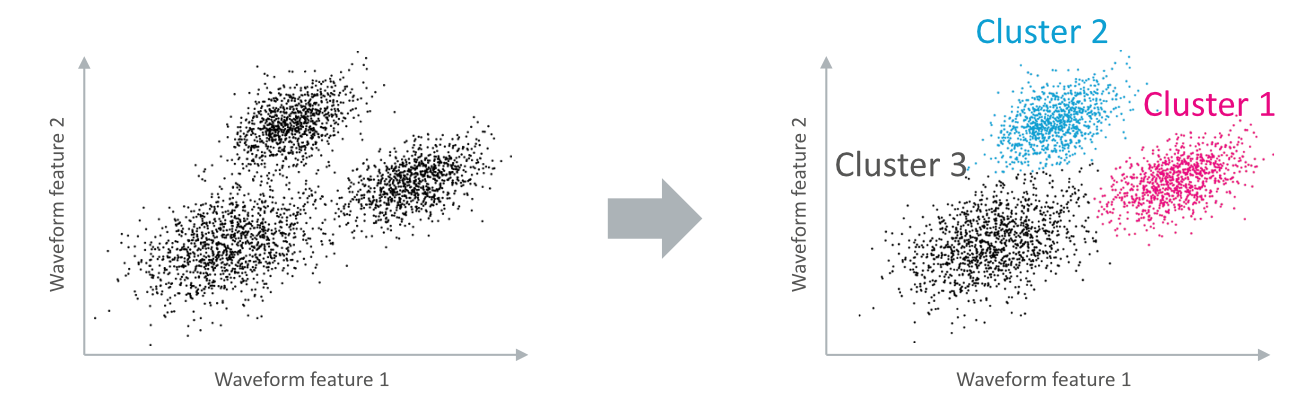

In this coding lab, we continue with the data from the first coding lab and finalize the Spike Sorting pipeline.
In particular, we use the created feature space to identify individual clusters by fitting a Gaussian Mixture Model.
To verify that this model does what we want, we first create a synthetic Toy Dataset and apply the model to that.

- __Data__: Use the saved data `nds_cl_1_*.npy` from Coding Lab 1. Or, if needed, download the data files ```nds_cl_1_*.npy``` from ILIAS and save it in the subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from __future__ import annotations

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2025-05-04 12:42:53W. Europe Daylight Time

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 9.1.0

sklearn: 1.6.1

sklearn   : 1.6.1
numpy     : 2.2.4
scipy     : 1.15.2
matplotlib: 3.10.1

Watermark: 2.5.0



In [2]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [3]:
# replace by path to your solutions
b = np.load("../data/nds_cl_1_features.npy")
s = np.load("../data/nds_cl_1_spiketimes_s.npy")
t = np.load("../data/nds_cl_1_spiketimes_t.npy")
w = np.load("../data/nds_cl_1_waveforms.npy")

## Task 1: Generate toy data

Sample 1000 data points from a two dimensional mixture of Gaussian model with three clusters  and the following parameters:

$\mu_1 = \begin{bmatrix}0\\0\end{bmatrix}, \Sigma_1 = \begin{bmatrix}1 & 0\\0 & 1\end{bmatrix}, \pi_1=0.3$

$\mu_2 = \begin{bmatrix}5\\1\end{bmatrix}, \Sigma_2 = \begin{bmatrix}2 & 1\\1 & 2\end{bmatrix}, \pi_2=0.5$

$\mu_3 = \begin{bmatrix}0\\4\end{bmatrix}, \Sigma_3 = \begin{bmatrix}1 & -0.5\\-0.5 & 1\end{bmatrix}, \pi_3=0.2$

Plot the sampled data points and indicate in color the cluster each point came from. Plot the cluster means as well.

*Grading: 2 pts*


In [4]:
def sample_data(
    n_samples: int, m: np.ndarray, S: np.ndarray, p: np.ndarray, random_seed: int = 0
) -> tuple[np.ndarray, np.ndarray]:
    """Generate n_samples samples from a Mixture of Gaussian distribution with
    means m, covariances S and priors p.

    Parameters
    ----------

    n_samples: int
        Number of samples

    m: np.ndarray, (n_clusters, n_dims)
        Means

    S: np.ndarray, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.ndarray, (n_clusters, )
        Cluster weights / probablities

    random_seed: int
        Random Seed

    Returns
    -------

    labels: np.array, (n_samples, )
        Grund truth labels.

    x: np.array, (n_samples, n_dims)
        Data points
    """
    # ensure reproducibility using a random number generator
    # hint: access random functions of this generator
    rng = np.random.default_rng(random_seed)

    # ------------------------------------------------------
    # draw labeled points from mixture of Gaussians (1 pt)
    # ------------------------------------------------------

    n_clusters, n_dims = m.shape

    labels = rng.choice(n_clusters, size=n_samples, p=p)
    x = np.zeros((n_samples, n_dims))
    for k in range(n_clusters):
        idx = labels == k
        n_k = idx.sum()
        if n_k > 0:
            x[idx] = rng.multivariate_normal(mean=m[k], cov=S[k], size=n_k)
    return labels, x

In [5]:
N = 1000  # total number of samples

p = np.array([0.3, 0.5, 0.2])  # percentage of each cluster
m = np.array([[0.0, 0.0], [5.0, 1.0], [0.0, 4.0]])  # means

S1 = np.array([[1.0, 0.0], [0.0, 1.0]])
S2 = np.array([[2.0, 1.0], [1.0, 2.0]])
S3 = np.array([[1.0, -0.5], [-0.5, 1.0]])
S = np.stack([S1, S2, S3])  # cov

labels, x = sample_data(N, m, S, p, random_seed=42)

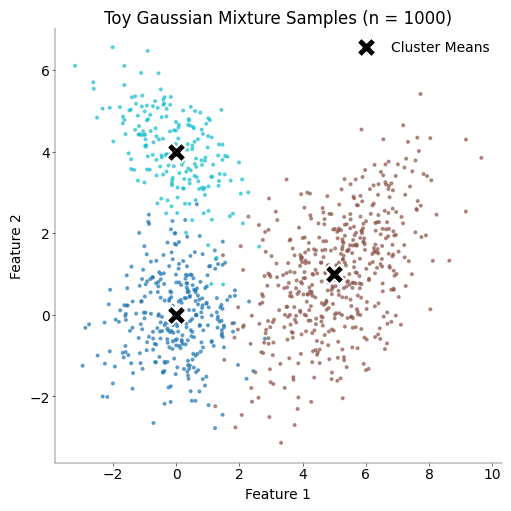

In [6]:
# ----------------------------------------------
# plot points from mixture of Gaussians (1 pt)
# ----------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")

scatter = ax.scatter(x[:, 0], x[:, 1], c=labels, cmap="tab10", s=15, alpha=0.6)
# plot the true means
ax.scatter(
    m[:, 0],
    m[:, 1],
    marker="X",
    s=200,
    c="black",
    edgecolor="white",
    linewidth=1.5,
    label="Cluster Means",
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Toy Gaussian Mixture Samples (n = 1000)")
ax.legend()
plt.show()

## Task 2: Implement a Gaussian mixture model

Implement the EM algorithm to fit a Gaussian mixture model in `fit_mog()`.  Sort the data points by inferring their class labels from your mixture model (by using maximum a-posteriori classification). Fix the seed of the random number generator to ensure deterministic and reproducible behavior. Test it on the toy dataset specifying the correct number of clusters and make sure the code works correctly. Plot the data points from the toy dataset and indicate in color the cluster each point was assigned to by your model. How does the assignment compare to ground truth? If you run the algorithm multiple times, you will notice that some solutions provide suboptimal clustering solutions - depending on your initialization strategy.  

*Grading: 6 pts*


In [7]:
def fit_mog(
    x: np.ndarray,
    n_clusters: int,
    n_iters: int = 10,
    random_seed: int = 0,
    init: str = "random",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Fit Mixture of Gaussian model using EM algo.

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    n_clusters: int
        Number of clusters

    n_iters: int
        Maximal number of iterations.

    random_seed: int
        Random Seed


    Returns
    -------

    labels: np.array, (n_samples)
        Cluster labels

    m: list or np.array, (n_clusters, n_dims)
        Means

    S: list or np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: list or np.array, (n_clusters, )
        Cluster weights / probablities
    """
    # ensure reproducibility using a random number generator
    rng = np.random.default_rng(random_seed)

    N, D = x.shape
    K = n_clusters

    # -----------
    # init (1 pt)
    # -----------

    if init == "kmeans":
        from sklearn.cluster import KMeans

        km = KMeans(n_clusters=K, random_state=random_seed).fit(x)
        m = km.cluster_centers_.copy()
    else:  # Random
        m = x[rng.choice(N, size=K, replace=False)].copy()

    # init covariances to data covariance, and equal weights
    S = np.array([np.cov(x, rowvar=False) for _ in range(K)])
    p = np.ones(K) / K

    # -------------------------
    # EM maximisation (3 pts)
    # -------------------------

    for it in range(n_iters):

        # E step
        # Evaluate the posterior probablibities `r`
        # using the current values of `m` and `S`
        r = np.zeros((N, K))
        for k in range(K):
            r[:, k] = p[k] * sp.stats.multivariate_normal.pdf(
                x, mean=m[k], cov=S[k], allow_singular=True
            )
        r_sum = r.sum(axis=1, keepdims=True)
        r /= r_sum

        # M step
        # Estimate new `m`, `S` and `p`
        N_k = r.sum(axis=0)
        p = N_k / N
        m = (r.T @ x) / N_k[:, None]
        for k in range(K):
            diff = x - m[k]
            S[k] = (r[:, k, None] * diff).T @ diff / N_k[k]
            S[k] += 1e-6 * np.eye(D)  # add a tiny regularizer for numeric stability

    labels = np.argmax(r, axis=1)
    return labels, m, S, p

Run Mixture of Gaussian on toy data

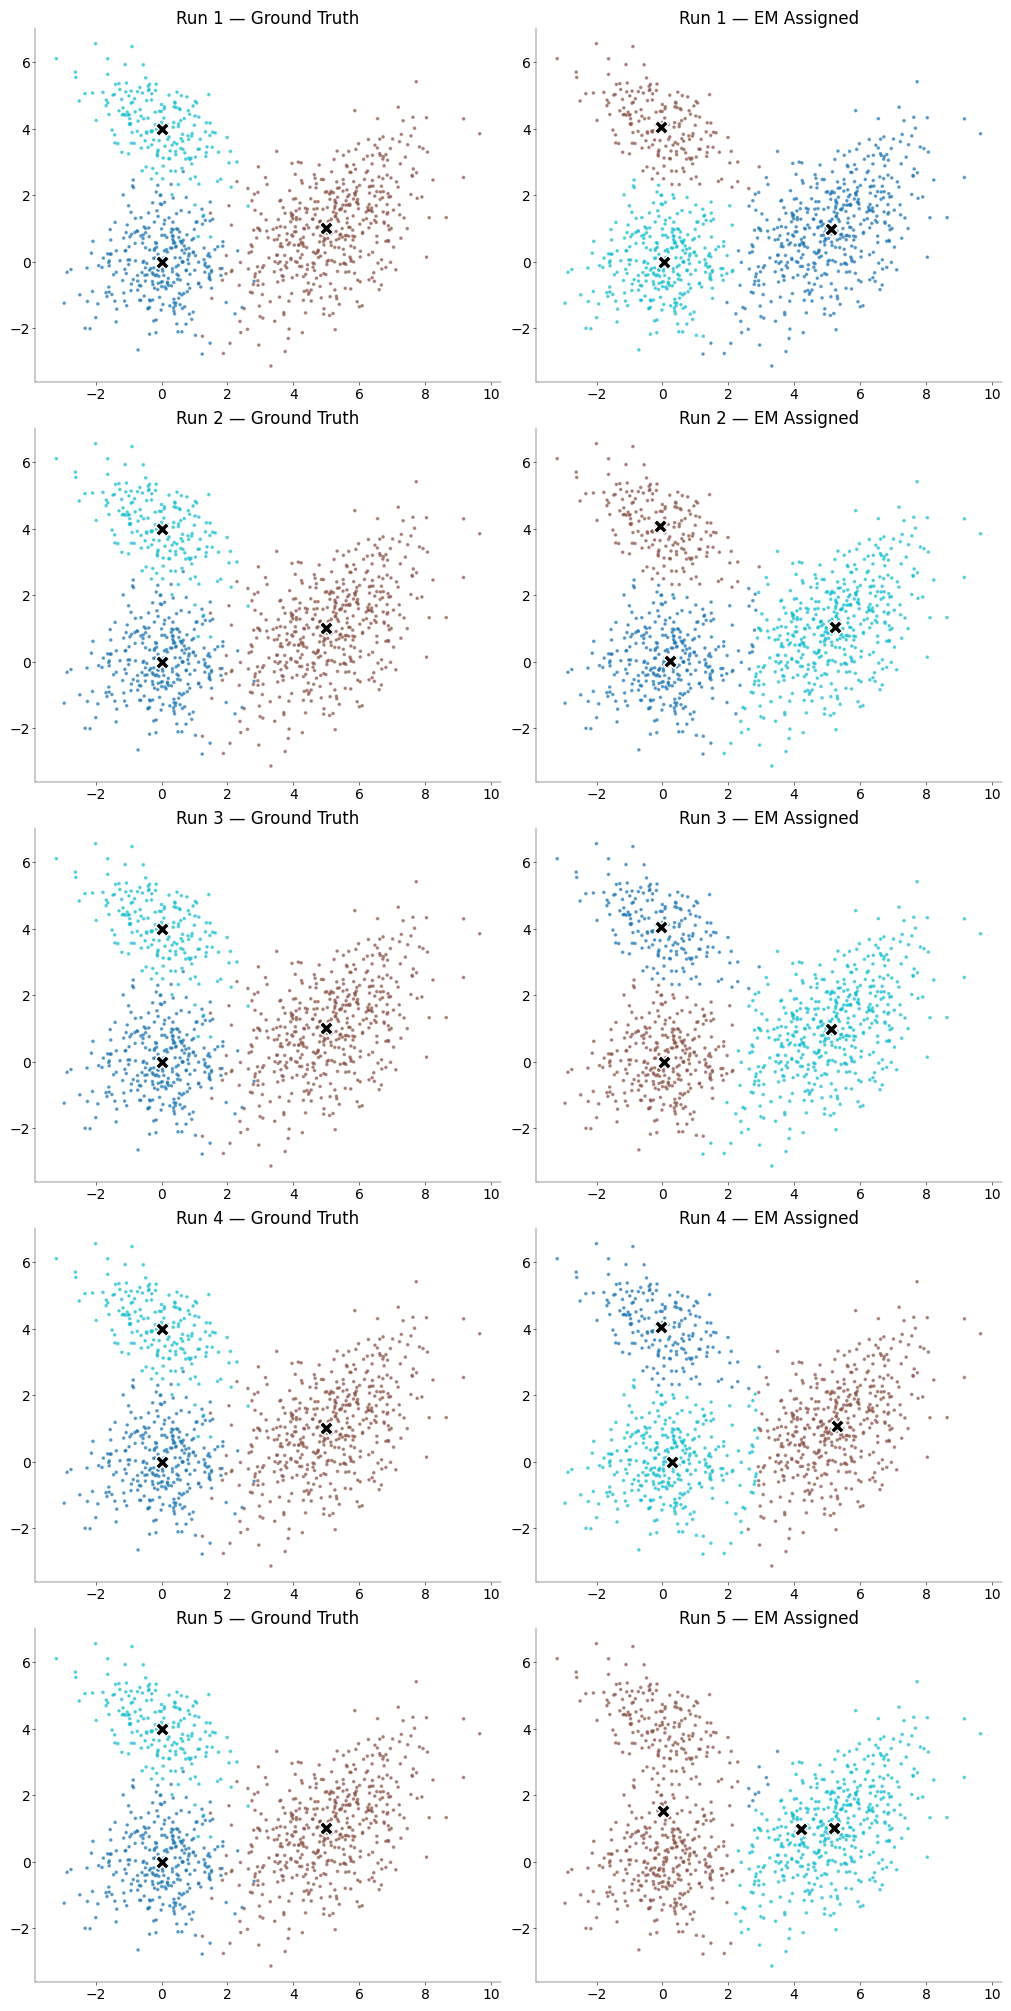

In [8]:
# -------------------------------------------------------------------------
# Run the algorithm 5 times on the toy data, plot and compare original and
# assigned clusters and answer the questions (1+1 pts)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(10, 20), constrained_layout=True)

for i in range(5):
    ax_gt, ax_em = axes[i]

    ax_gt.scatter(x[:, 0], x[:, 1], c=labels, cmap="tab10", s=10, alpha=0.6)
    ax_gt.set_title(f"Run {i+1} — Ground Truth")
    ax_gt.scatter(m[:, 0], m[:, 1], marker="X", c="k", s=100, edgecolor="white")

    labels_em, m_em, S_em, p_em = fit_mog(
        x, n_clusters=3, n_iters=20, random_seed=i * 7
    )
    ax_em.scatter(x[:, 0], x[:, 1], c=labels_em, cmap="tab10", s=10, alpha=0.6)
    ax_em.set_title(f"Run {i+1} — EM Assigned")
    ax_em.scatter(m_em[:, 0], m_em[:, 1], marker="X", c="k", s=100, edgecolor="white")

plt.show()

### Questions

1) Do all runs converge to good solutions? If not, which one would you pick (only visual inspection required) as the best one?

    Not all runs converge to equally good solutions. In our five trials, some runs (e.g. run 5) clearly merge two true clusters into one or split a single cluster into two. By visual inspection, the run that best recovers the three clusters is run 1.

2) Do you get the same colors (=labels) in your best assignment(s) compared to the groundtruth? Does it have to be that way or not? Why?

    No, we do not necessarily see the same color-to-cluster mapping between your best EM run and the ground-truth plot. GMM labels are inherently unlabeled: component 0, 1, 2 in your EM fit are assigned arbitrarily, so “cluster 0” in EM might correspond to “cluster 2” in the true labels. What matters is the partitioning of the points, not the specific numeric or color label. In other words, a permutation of colors doesn’t affect the quality of the clustering, only the grouping structure does.

## Bonus Task (Optional): Mixture of drifting t-distributions

Instead of a simple Gaussian Mixture Model, more advanced algorithms can be implemented.
Implement a basic version of the mixture of drifting t-distributions (follow https://github.com/aecker/moksm/blob/master/MoT_Kalman.pdf).
What is the advantage of that method?

_Grading: 2 BONUS Points._


_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [9]:
# YOUR CODE HERE
import numpy as np
from scipy.special import gammaln
from scipy.linalg import inv


class MixtureDriftingTDist:
    """
    Mixture of drifting multivariate t-distributions.
    EM alternates between:
      - E-step: responsibilities r_{ik} and t-latent scales u_{ik}
      - M-step: update mixture weights p_k, covariances Σ_k, and
        time-varying means μ_{k,t} via Kalman filter + Rauch-Tung-Striebel smoother.
    """

    def __init__(
        self,
        n_components: int,
        df: float,
        Q: np.ndarray,
        dt: float = 1.0,
        random_seed: int = 0,
    ):
        """
        Parameters
        ----------
        n_components : int
          Number of mixture components K.

        df : float
          Degrees of freedom for the t-distribution (fixed).

        Q : (D,D) array
          Drift covariance for the random-walk prior on μ_t.

        dt : float
          Time-bin width (i.e., τ_t in the update equations).

        random_seed : int
          RNG seed for reproducibility.
        """
        self.K = n_components
        self.df = df
        self.Q = Q
        self.dt = dt
        self.rng = np.random.default_rng(random_seed)

        # to be learned:
        self.p: np.ndarray  # (K,) mixture weights
        self.Sigma: np.ndarray  # (K, D, D) covariances
        self.mu: np.ndarray  # (K, T, D) drifting means

    def _init_params(self, Y, t_idx, T):
        N, D = Y.shape
        # uniform weights
        self.p = np.ones(self.K) / self.K
        # initialize Σ_k to overall sample covariance
        cov0 = np.cov(Y, rowvar=False)
        self.Sigma = np.array([cov0.copy() for _ in range(self.K)])
        # random hard labels → initial μ_{k,t} by bin-wise averages
        labels = self.rng.choice(self.K, size=N, p=self.p)
        self.mu = np.zeros((self.K, T, D))
        for k in range(self.K):
            for ti in range(T):
                idx = np.where((labels == k) & (t_idx == ti))[0]
                if idx.size:
                    self.mu[k, ti] = Y[idx].mean(axis=0)
                else:
                    self.mu[k, ti] = Y.mean(axis=0)

    def _kalman_smoother(self, Y, t_idx, r, u, Σ_k, Q, T):
        """
        Forward (KF) + backward (RTS) to update μ_{1:T} for one component k.

        Ecker et al. eqs. (54)–(59):
          P_{t|t} = (τ_t u_t Σ^{-1} + P_{t|t-1}^{-1})^{-1},
          μ_{t|t} = P_{t|t}(τ_t u_t Σ^{-1} y_t + P_{t|t-1}^{-1}μ_{t|t-1}) :contentReference[oaicite:0]{index=0}
        and RTS smoother (eq. 64) for the backwards pass. :contentReference[oaicite:1]{index=1}
        """
        N, D = Y.shape
        τ = self.dt

        # 1) form bin-wise weighted means ȳ_t and weights W_t = Σ_i (r_i u_i τ)
        ybar = np.zeros((T, D))
        W = np.zeros(T)
        w = r * u * τ
        for i in range(N):
            ti = t_idx[i]
            ybar[ti] += w[i] * Y[i]
            W[ti] += w[i]
        nonzero = W > 0
        ybar[nonzero] /= W[nonzero][:, None]

        # 2) forward Kalman pass
        μ_pred = np.zeros((T, D))
        P_pred = np.zeros((T, D, D))
        μ_filt = np.zeros((T, D))
        P_filt = np.zeros((T, D, D))

        # init with very large uncertainty
        μ_prev = ybar[0] if nonzero[0] else np.zeros(D)
        P_prev = np.eye(D) * 1e6

        Σ_inv = inv(Σ_k)
        for t in range(T):
            # predict
            μ_pred[t] = μ_prev
            P_pred[t] = P_prev + Q

            if W[t] > 0:
                P0_inv = inv(P_pred[t])
                # update
                P_filt[t] = inv(W[t] * Σ_inv + P0_inv)
                μ_filt[t] = P_filt[t] @ (W[t] * (Σ_inv @ ybar[t]) + P0_inv @ μ_pred[t])
            else:
                μ_filt[t] = μ_pred[t]
                P_filt[t] = P_pred[t]

            μ_prev, P_prev = μ_filt[t], P_filt[t]

        # 3) backward RTS smoother
        μ_smooth = np.zeros_like(μ_filt)
        μ_smooth[-1] = μ_filt[-1]
        for t in range(T - 2, -1, -1):
            P_f = P_filt[t]
            P_p = P_pred[t + 1]
            A = P_f @ inv(P_p)
            μ_smooth[t] = μ_filt[t] + A @ (μ_smooth[t + 1] - μ_pred[t + 1])

        return μ_smooth

    def fit(self, Y: np.ndarray, t: np.ndarray, n_iters: int = 10):
        """
        Fit the mixture to data Y ∈ R^{N×D} with time indices t.

        Returns
        -------
        self
        """
        # map arbitrary t to integer 0..T-1
        t_unique = np.unique(t)
        t_to_idx = {val: i for i, val in enumerate(t_unique)}
        t_idx = np.array([t_to_idx[val] for val in t])
        T = len(t_unique)

        # initialize
        self._init_params(Y, t_idx, T)
        N, D = Y.shape

        for it in range(n_iters):
            # --- E-step ---
            δ2 = np.zeros((N, self.K))
            pdf = np.zeros((N, self.K))

            for k in range(self.K):
                μ_kt = self.mu[k, t_idx]  # N×D
                diff = Y - μ_kt
                Σ_k = self.Sigma[k]
                Σ_inv = inv(Σ_k)
                δ2[:, k] = np.sum(diff @ Σ_inv * diff, axis=1)
                # multivariate t‐pdf
                C = np.exp(gammaln((self.df + D) / 2) - gammaln(self.df / 2)) / (
                    (self.df * np.pi) ** (D / 2) * np.sqrt(np.linalg.det(Σ_k))
                )
                pdf[:, k] = C * (1 + δ2[:, k] / self.df) ** (-(self.df + D) / 2)

            # responsibilities
            r = self.p * pdf
            r /= r.sum(axis=1, keepdims=True)

            # latent scales
            u = (self.df + D) / (self.df + δ2)

            # --- M-step ---
            N_k = r.sum(axis=0)
            self.p = N_k / N

            for k in range(self.K):
                # update Σ_k
                rk = r[:, k]
                uk = u[:, k]
                diff = Y - self.mu[k, t_idx]
                weighted = (rk * uk)[:, None] * diff
                Σ_new = (diff.T @ weighted) / N_k[k]
                self.Sigma[k] = Σ_new + 1e-6 * np.eye(D)

                # update μ via Kalman + RTS smoother
                self.mu[k] = self._kalman_smoother(
                    Y, t_idx, rk, uk, self.Sigma[k], self.Q, T
                )

        return self

In [10]:
x_toy = x
labels_true = labels
m_true = m

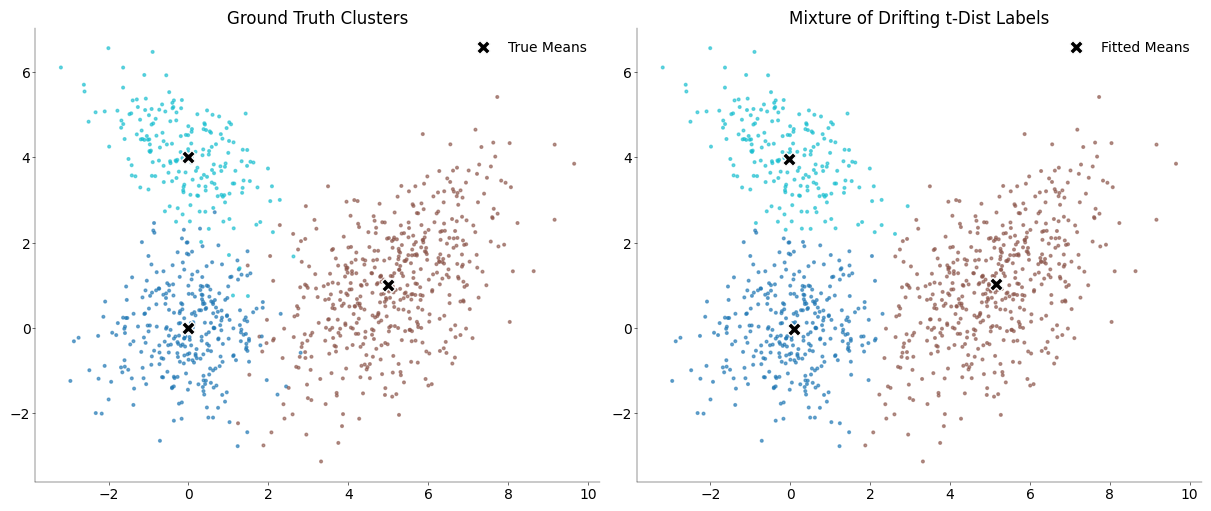

In [11]:
def predict_mot(model, Y, t):

    from scipy.linalg import inv
    from scipy.special import gammaln

    # remap t to 0..T-1
    t_unique = np.unique(t)
    t_to_idx = {val: i for i, val in enumerate(t_unique)}
    t_idx = np.array([t_to_idx[val] for val in t])
    N, D = Y.shape

    # compute t‐pdf for each component
    δ2 = np.zeros((N, model.K))
    pdf = np.zeros_like(δ2)
    for k in range(model.K):
        Σ_k = model.Sigma[k]
        Σ_inv = inv(Σ_k)
        μ_kt = model.mu[k, t_idx]  # (N×D)
        diff = Y - μ_kt
        δ2[:, k] = np.sum(diff @ Σ_inv * diff, axis=1)
        C = np.exp(gammaln((model.df + D) / 2) - gammaln(model.df / 2)) / (
            (model.df * np.pi) ** (D / 2) * np.sqrt(np.linalg.det(Σ_k))
        )
        pdf[:, k] = C * (1 + δ2[:, k] / model.df) ** (-(model.df + D) / 2)

    # responsibilities and labels
    r = model.p * pdf
    r /= r.sum(axis=1, keepdims=True)
    return np.argmax(r, axis=1)


# For static data we use a single time‐bin t=0 for all points
t = np.zeros(N, dtype=int)

# ——— Fit Mixture of Drifting t-Distributions ———
Q = np.eye(2) * 0.01  # small drift covariance
model = MixtureDriftingTDist(n_components=3, df=4, Q=Q, dt=1.0, random_seed=0)
model.fit(x_toy, t, n_iters=20)

# ——— Assign labels and plot ———
labels_mot = predict_mot(model, x_toy, t)
fitted_means = model.mu[:, 0]  # (3 × 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Ground truth
axes[0].scatter(x_toy[:, 0], x_toy[:, 1], c=labels_true, cmap="tab10", s=15, alpha=0.6)
axes[0].scatter(
    m_true[:, 0],
    m_true[:, 1],
    marker="X",
    c="black",
    s=100,
    edgecolor="white",
    label="True Means",
)
axes[0].set_title("Ground Truth Clusters")
axes[0].legend()

# MoT-tdist fit
axes[1].scatter(x_toy[:, 0], x_toy[:, 1], c=labels_mot, cmap="tab10", s=15, alpha=0.6)
axes[1].scatter(
    fitted_means[:, 0],
    fitted_means[:, 1],
    marker="X",
    c="black",
    s=100,
    edgecolor="white",
    label="Fitted Means",
)
axes[1].set_title("Mixture of Drifting t-Dist Labels")
axes[1].legend()

plt.show()

## Task 3: Model complexity
A priori we do not know how many neurons we recorded. Extend your algorithm with an automatic procedure to select the appropriate number of mixture components (clusters). Base your decision on the Bayesian Information Criterion:

$BIC = -2L+P \log N,$

where $L$ is the log-likelihood of the data under the best model, $P$ is the number of parameters of the model and $N$ is the number of data points. You want to minimize the quantity. Plot the BIC as a function of mixture components. What is the optimal number of clusters on the toy dataset?

You can also use the BIC to make your algorithm robust against suboptimal solutions due to local minima. Start the algorithm multiple times and pick the best solutions. You will notice that this depends a lot on which initialization strategy you use.

*Grading: 5 pts*



### Question (0.5 pts)

1) What is the number of parameters of the model?

The total number of free parameters in a $K$-component, $D$-dimensional Gaussian mixture is

$$
P = \underbrace{K\,D}_{\text{means}} + \underbrace{K\,\frac{D(D+1)}{2}}_{\text{covariances}} + \underbrace{(K-1)}_{\text{mixing weights}}
$$

So a total of

$$
P = K\,D + \frac{K\,D(D+1)}{2} + (K-1).
$$

In [12]:
def mog_bic(
    x: np.ndarray, m: np.ndarray, S: np.ndarray, p: np.ndarray
) -> tuple[float, float]:
    """Compute the BIC for a fitted Mixture of Gaussian model

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    m: np.array, (n_clusters, n_dims)
        Means

    S: np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.array, (n_clusters, )
        Cluster weights / probablities

    Return
    ------

    bic: float
        BIC

    LL: float
        Log Likelihood
    """

    # -------------------------
    # implement the BIC (1.5 pts)
    # -------------------------

    N, D = x.shape
    K = m.shape[0]

    pdf = np.zeros((N, K))
    for k in range(K):
        pdf[:, k] = p[k] * sp.stats.multivariate_normal.pdf(
            x, mean=m[k], cov=S[k], allow_singular=True
        )
    px = pdf.sum(axis=1)
    LL = np.sum(np.log(px))

    P = K * D + K * D * (D + 1) / 2 + (K - 1)

    bic = -2 * LL + P * np.log(N)
    return bic, LL

In [15]:
# ----------------------------------------------------------------------------------------------------------------------
# Compute and plot the BIC for mixture models with different numbers of clusters (e.g., 2 - 6). (0.5 pts)
# Make your _estimate of the BIC_ robust against local minima, regardless of the initialization strategy used (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

K_range = np.arange(2, 7)
num_seeds = 10

BICs = np.zeros((num_seeds, len(K_range)))
LLs = np.zeros((num_seeds, len(K_range)))

# run mog and BIC multiple times here
for i, K in enumerate(K_range):
    for seed in range(num_seeds):
        labels_em, m_em, S_em, p_em = fit_mog(
            x_toy, n_clusters=K, n_iters=20, random_seed=seed
        )
        bic, ll = mog_bic(x_toy, m_em, S_em, p_em)
        BICs[seed, i] = bic
        LLs[seed, i] = ll

BIC_robust = BICs.min(axis=0)
best_seed = np.argmin(BICs, axis=0)
LL_robust = LLs[best_seed, np.arange(len(K_range))]

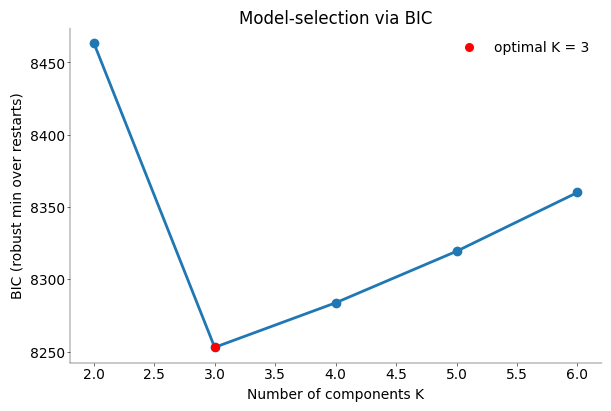

Optimal number of clusters (min BIC): 3


In [16]:
# ------------------------------------------------------------------------------------------
# Plot the result and answer the questions (1+1 pts)
# Don't forget to plot your robust estimate and highlight the estimated number of clusters!
# ------------------------------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(K_range, BIC_robust, marker="o", linewidth=2)
opt_idx = np.argmin(BIC_robust)
opt_K = K_range[opt_idx]
plt.scatter(
    opt_K, BIC_robust[opt_idx], s=120, c="red", zorder=5, label=f"optimal K = {opt_K}"
)
plt.xlabel("Number of components K")
plt.ylabel("BIC (robust min over restarts)")
plt.title("Model‐selection via BIC")
plt.legend()
plt.show()

print(f"Optimal number of clusters (min BIC): {opt_K}")

### Questions

1) What happens to the BIC if the model got stuck in a local minimum? For your reasoning, you can also refer to Task 2.

When EM gets stuck in a poor local optimum, the fitted GMM achieves a lower log-likelihood L than it could under a better solution. Because
$$
BIC =−2 L + P \log⁡ N,
$$

a decrease in L (worse fit) directly increases the −2L term, and thus raises the BIC. In other words, suboptimal clustering (as we saw in Task 2’s bad runs) yields a higher (worse) BIC compared to a run that found the true modes. This is why bad initializations not only produce visually poor clusterings but are also penalized numerically by BIC.

2) The goal is to estimate which number of clusters best fits the data using the BIC. Therefore, what qualifies as a robust estimate? Explain your reasoning!
   
_(Hint: think about which number of cluster you would use and why)_

A robust estimate of the number of clusters should be insensitive to initialization and reflect the model that consistently achieves the lowest BIC. 

Multiple restarts per $K$ guard against unlucky seeds: for each candidate $K$, we take the minimum BIC over all initializations so that we’re always evaluating the best possible fit for that $K$. 

We then choose the $K$ whose robust BIC (minimum across seeds) is lowest among all candidates.

This procedure ensures our selected $K$ isn’t an artifact of a single EM run but rather the number of clusters that reliably yields the best trade-off between data fit and model complexity.

## Task 4: Spike sorting using Mixture of Gaussian 
Run the full algorithm on your set of extracted features (MoG fitting + model complexity selection).

Show the plot of the BIC as a function of the number of mixture components on the real data, highlight the robust estimate and based on that the best number of clusters.

For the best model, make scatter plots of the first PCs on all four channels (6 plots). Color-code each data point according to its class label in the model with the optimal number of clusters. In addition, indicate the position (mean) of the clusters in your plot.

*Grading: 3 pts*


In [17]:
# replace by path to your solutions
b = np.load("../data/nds_cl_1_features.npy")
s = np.load("../data/nds_cl_1_spiketimes_s.npy")
t = np.load("../data/nds_cl_1_spiketimes_t.npy")
w = np.load("../data/nds_cl_1_waveforms.npy")

In [18]:
# -------------------------------------------------------------
# Run the algorithm on the set of extracted features (0.5 pts)
# -------------------------------------------------------------

K = np.arange(2, 16)
num_seeds = 5

BIC = np.zeros((num_seeds, len(K)))
LL = np.zeros((num_seeds, len(K)))

for i, Ki in enumerate(K):
    for seed in range(num_seeds):
        print(f"Clusters: {Ki}, Seed: {seed}")
        labels_em, m_em, S_em, p_em = fit_mog(
            b, n_clusters=Ki, n_iters=20, random_seed=seed, init="kmeans"
        )  # using kmeans init for stability
        bic, ll = mog_bic(b, m_em, S_em, p_em)
        BIC[seed, i] = bic
        LL[seed, i] = ll

Clusters: 2, Seed: 0
Clusters: 2, Seed: 1
Clusters: 2, Seed: 2
Clusters: 2, Seed: 3
Clusters: 2, Seed: 4
Clusters: 3, Seed: 0
Clusters: 3, Seed: 1
Clusters: 3, Seed: 2
Clusters: 3, Seed: 3
Clusters: 3, Seed: 4
Clusters: 4, Seed: 0
Clusters: 4, Seed: 1
Clusters: 4, Seed: 2
Clusters: 4, Seed: 3
Clusters: 4, Seed: 4
Clusters: 5, Seed: 0
Clusters: 5, Seed: 1
Clusters: 5, Seed: 2
Clusters: 5, Seed: 3
Clusters: 5, Seed: 4
Clusters: 6, Seed: 0
Clusters: 6, Seed: 1
Clusters: 6, Seed: 2
Clusters: 6, Seed: 3
Clusters: 6, Seed: 4
Clusters: 7, Seed: 0
Clusters: 7, Seed: 1
Clusters: 7, Seed: 2
Clusters: 7, Seed: 3
Clusters: 7, Seed: 4
Clusters: 8, Seed: 0
Clusters: 8, Seed: 1
Clusters: 8, Seed: 2
Clusters: 8, Seed: 3
Clusters: 8, Seed: 4
Clusters: 9, Seed: 0
Clusters: 9, Seed: 1
Clusters: 9, Seed: 2
Clusters: 9, Seed: 3
Clusters: 9, Seed: 4
Clusters: 10, Seed: 0
Clusters: 10, Seed: 1
Clusters: 10, Seed: 2
Clusters: 10, Seed: 3
Clusters: 10, Seed: 4
Clusters: 11, Seed: 0
Clusters: 11, Seed: 1
Cluste

In [19]:
BIC_robust = BIC.min(axis=0)
opt_idx = np.argmin(BIC_robust)
opt_K = K[opt_idx]

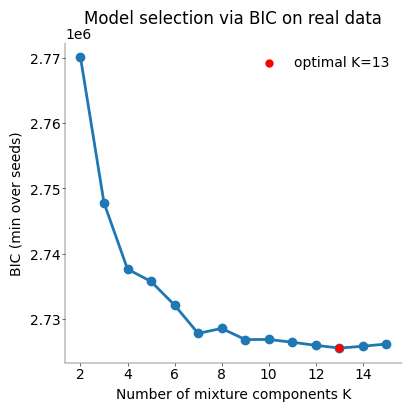

In [20]:
# ----------------------------------------------------------------------------------------------------------------------
# Plot the BIC over number of mixture components and highlight robust estimate and optimal number of clusters (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(K, BIC_robust, marker="o", linewidth=2)
ax.scatter(
    opt_K, BIC_robust[opt_idx], s=100, c="red", zorder=5, label=f"optimal K={opt_K}"
)
ax.set_xlabel("Number of mixture components K")
ax.set_ylabel("BIC (min over seeds)")
ax.set_title("Model selection via BIC on real data")
ax.legend()
plt.show()

Refit model with lowest BIC and plot data points

In [21]:
seed_idx, k_idx = np.where(BIC == BIC_robust.min())
best_seed = seed_idx[0]
print(f"Lowest BIC at K={opt_K}, seed={best_seed}")

labels_best, m_best, S_best, p_best = fit_mog(
    b, n_clusters=opt_K, n_iters=20, random_seed=best_seed, init="kmeans"
)

Lowest BIC at K=13, seed=2


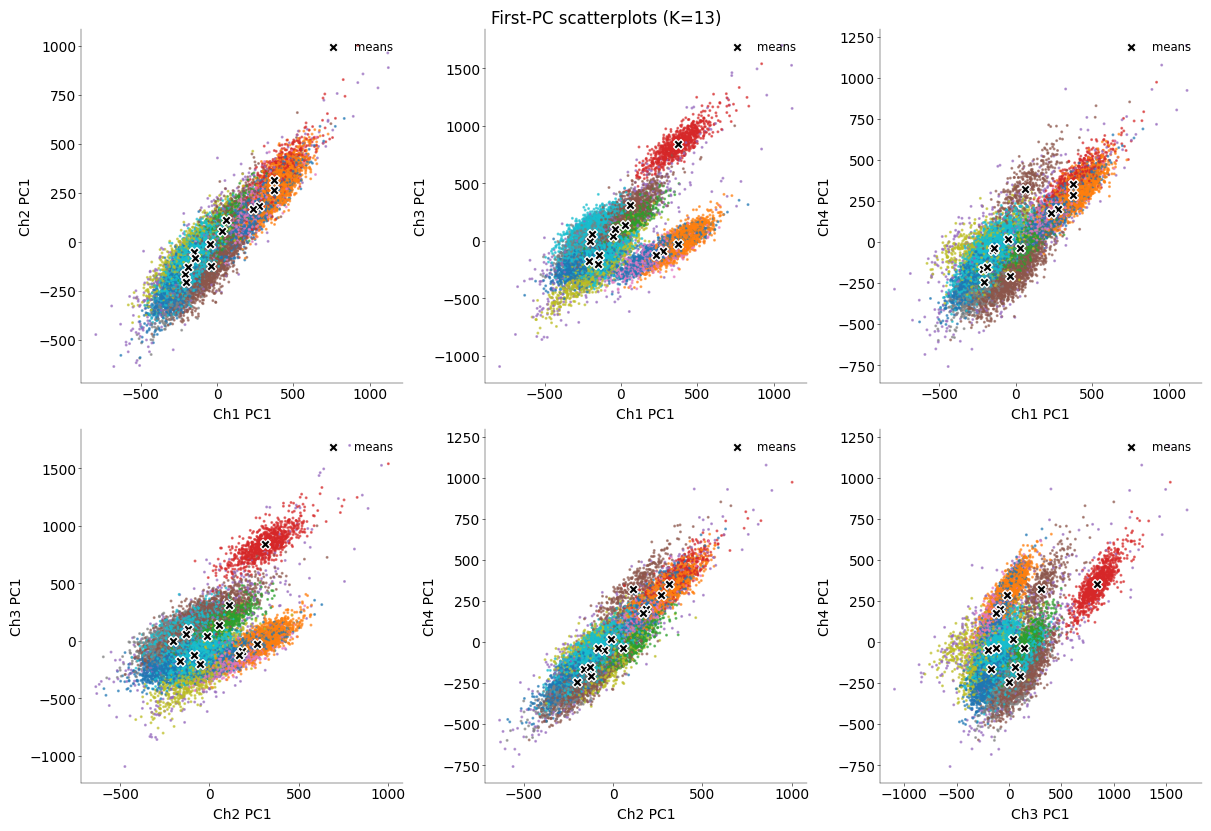

In [22]:
# ------------------------------------------------------------------------------------------------------------------
# Create scatterplots of the first PCs under the best model for all pairwise combinations of the 4 channels. (1 pt)
# ------------------------------------------------------------------------------------------------------------------
pc1_idx = [0, 3, 6, 9]
pc_names = ["Ch1 PC1", "Ch2 PC1", "Ch3 PC1", "Ch4 PC1"]
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
for ax, (i, j) in zip(axes.flat, pairs):
    xi = b[:, pc1_idx[i]]
    xj = b[:, pc1_idx[j]]
    ax.scatter(xi, xj, c=labels_best, cmap="tab10", s=5, alpha=0.6)
    # plot cluster means
    mi = m_best[:, pc1_idx[i]]
    mj = m_best[:, pc1_idx[j]]
    ax.scatter(mi, mj, marker="X", c="k", s=50, edgecolor="white", label="means")
    ax.set_xlabel(pc_names[i])
    ax.set_ylabel(pc_names[j])
    ax.legend(loc="upper right", fontsize="small")

fig.suptitle(f"First‐PC scatterplots (K={opt_K})", y=1.02)
plt.show()

## Task 5: Cluster separation and Correlograms

As postprocessing, implement the calculation of auto- and cross correlograms over the spike times.

Plot the (auto-/cross-) correlograms, displaying a time frame of -30ms to +30ms. Choose a good bin size and interprete the resulting diagrams.

_Grading: 3 pts_

#### Hints

_It is faster to calculate the histogram only over the spiketimes that are in the displayed range. Filter the spike times before calculating the histogram!_

_For the autocorrelogram, make sure not to include the time difference between a spike and itself (which would be exactly 0)_

_For the correlogram an efficient implementation is very important - looping over all spike times is not feasible. Instead, make use of numpy vectorization and broadcasting - you can use functions such as tile or repeat._

In [23]:
# ----------------------------------------------------------------------
# Implement a function for calculating the spike time differences (1pt)
# ----------------------------------------------------------------------
def cross_time_diff(spiketimes1: np.ndarray, spiketimes2: np.ndarray) -> np.ndarray:
    """Compute the pairwise time differences between two sets of spike times.

    Parameters
    ----------
    spiketimes1: np.ndarray, (n_spikes1, )
        Spike times of the first cluster
    spiketimes2: np.ndarray, (n_spikes2, )
        Spike times of the second cluster

    Return
    ------

    time_diff: np.ndarray, (n_spikes1, n_spikes2)
        Pairwise time differences between the two sets of spike times
        (i.e., spiketimes1[i] - spiketimes2[j])
    """
    return spiketimes1[:, None] - spiketimes2[None, :]

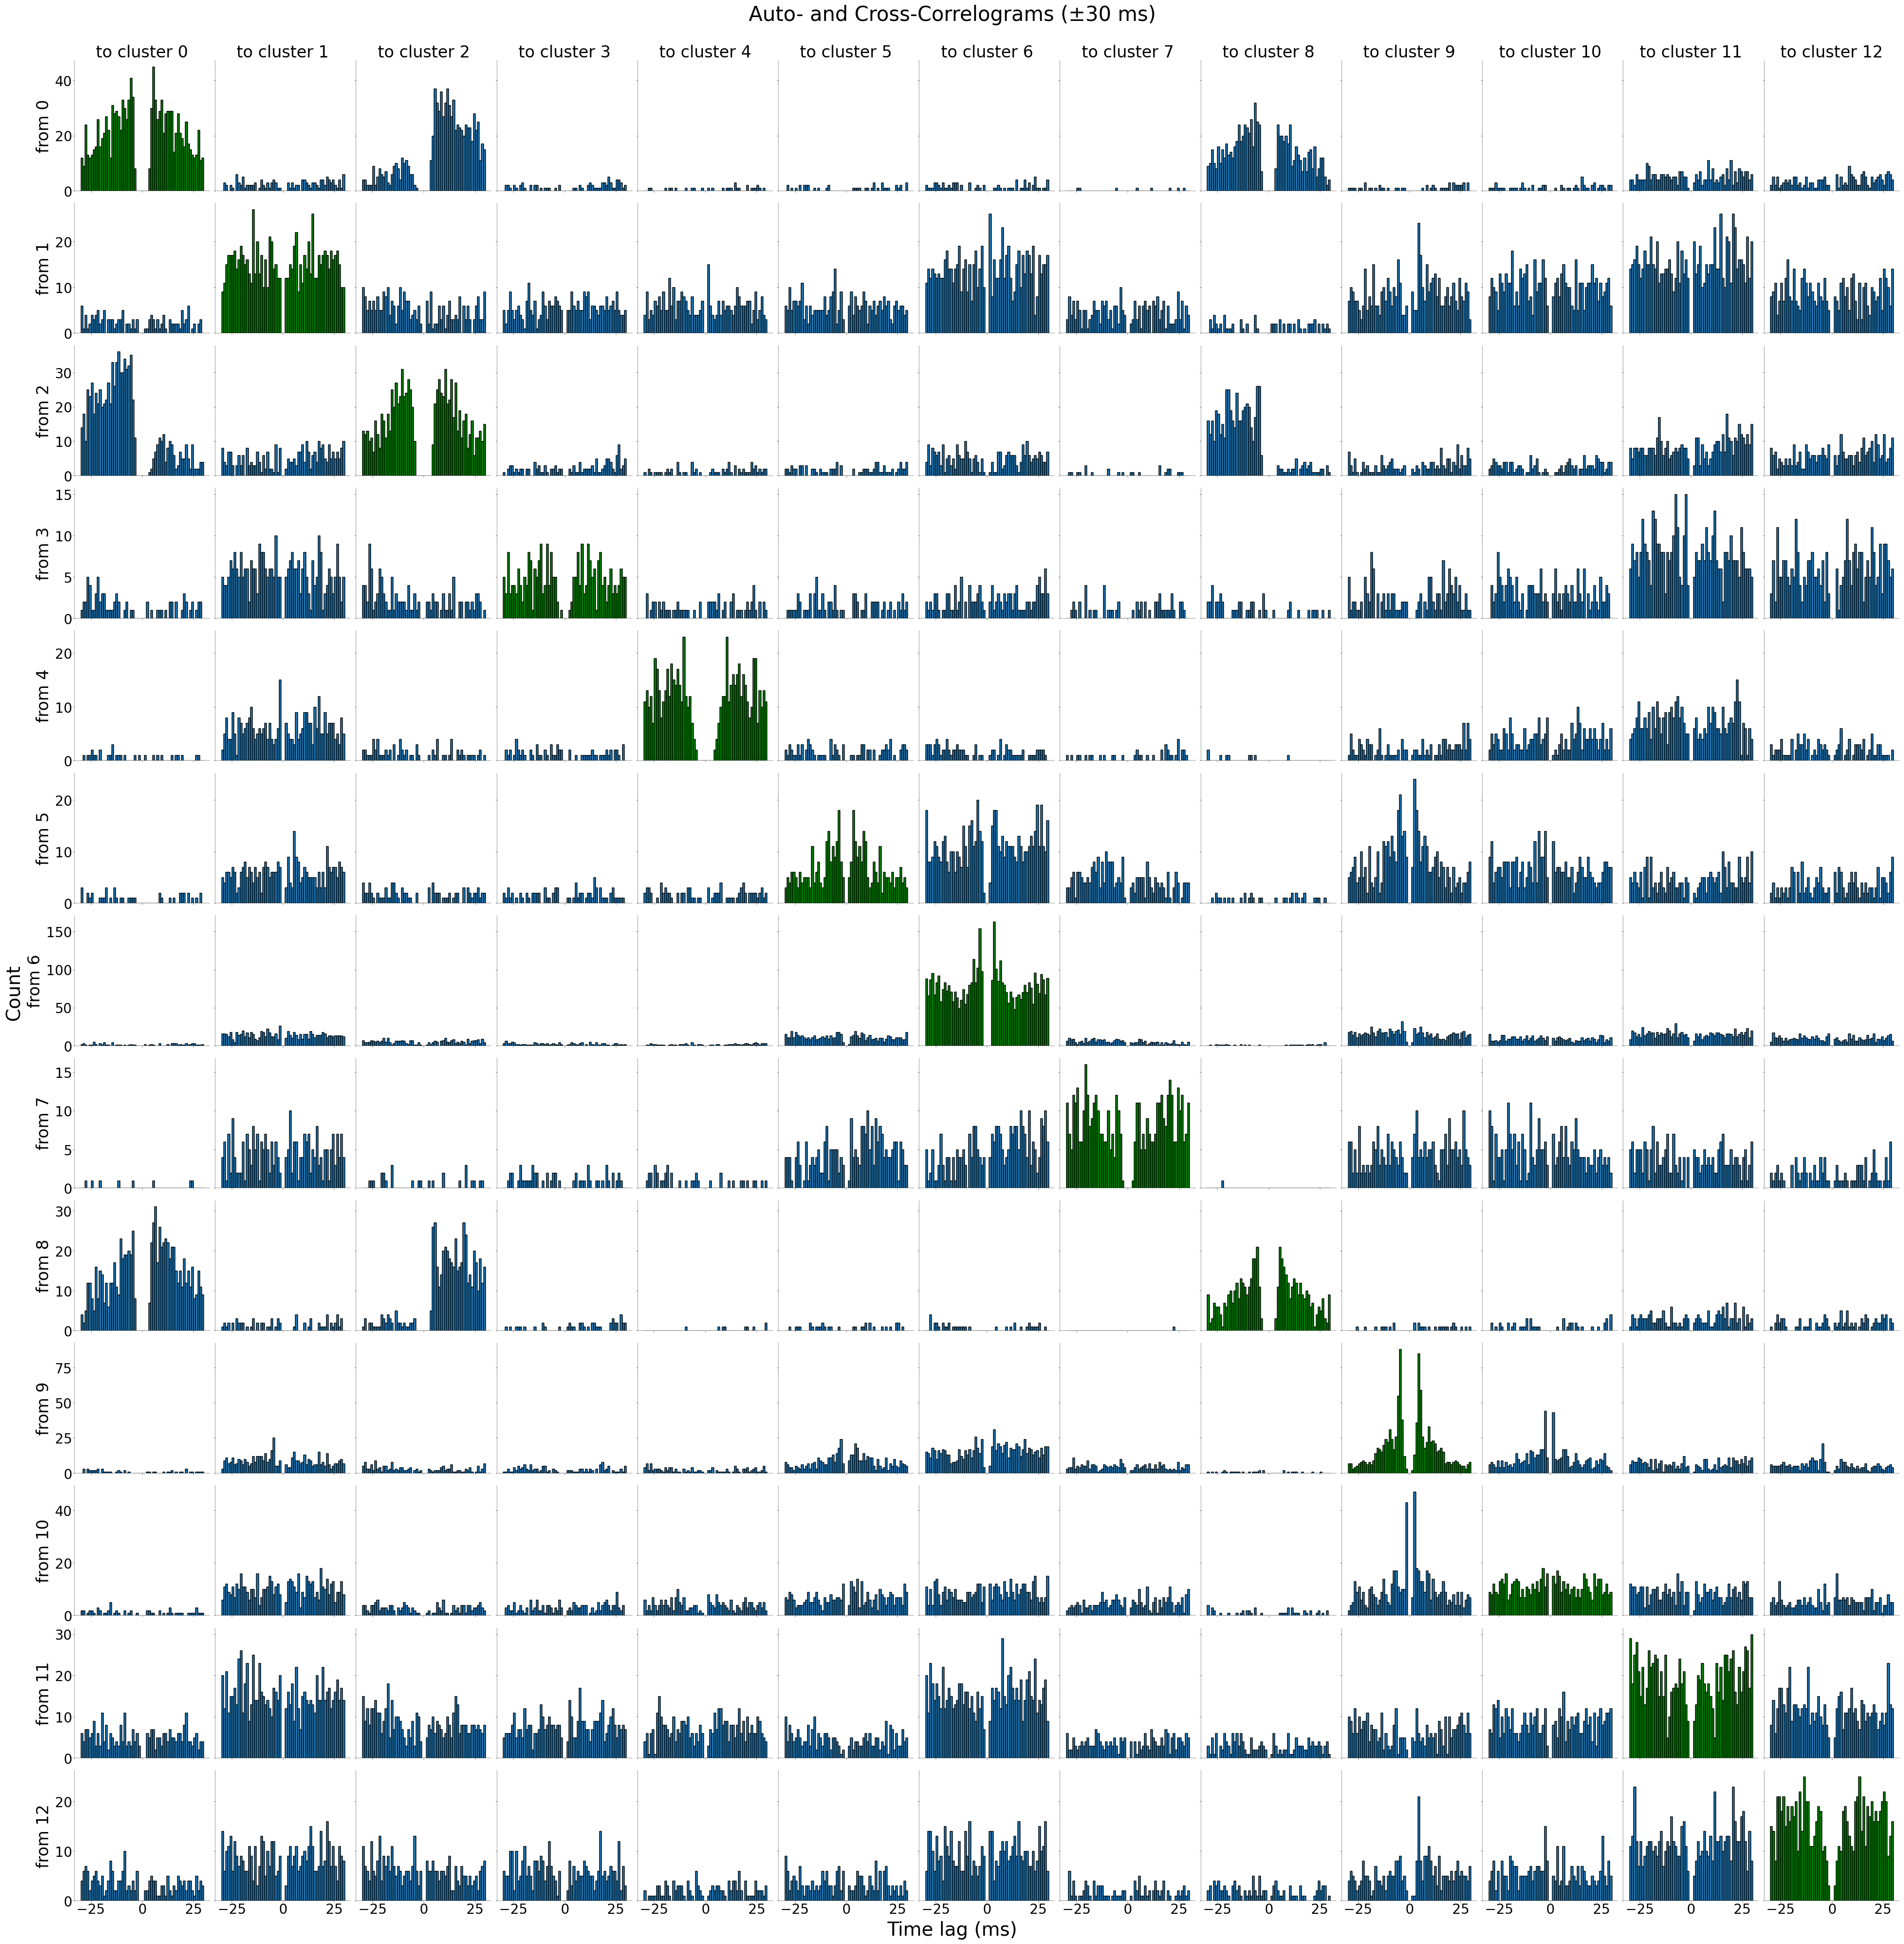

In [43]:
# -----------------------------------------------------------------------------------
# Calculate and plot auto- and cross-correlograms and answer the questions (1+1 pts)
# -----------------------------------------------------------------------------------
window = 30.0
bin_size = 1.0
bins = np.arange(-window, window + bin_size, bin_size)

# cluster IDs
cluster_ids = np.unique(labels_best)
K = len(cluster_ids)

# share x across columns, share y only within each row
fig, axes = plt.subplots(
    K, K, figsize=(3 * K, 3 * K), sharex=True, sharey="row", constrained_layout=True
)

row_max = np.zeros(K)

for ii, ci in enumerate(cluster_ids):
    times_i = t[labels_best == ci]
    for jj, cj in enumerate(cluster_ids):
        ax = axes[ii, jj]
        times_j = t[labels_best == cj]

        dt = cross_time_diff(times_i, times_j)
        if ci == cj:
            dt = dt[~np.eye(dt.shape[0], dtype=bool)]
        else:
            dt = dt.ravel()

        dt = dt[(dt >= -window) & (dt <= window)]
        counts, _ = np.histogram(dt, bins=bins)

        centers = (bins[:-1] + bins[1:]) / 2

        if ci == cj:
            ax.bar(centers, counts, width=bin_size, color="green", edgecolor="black")
        else:
            ax.bar(centers, counts, width=bin_size, edgecolor="black")

        # track max for this row
        row_max[ii] = max(row_max[ii], counts.max())

        # larger titles/labels
        if ii == 0:
            ax.set_title(f"to cluster {cj}", fontsize=24)
        if jj == 0:
            ax.set_ylabel(f"from {ci}", fontsize=24)

        # larger tick labels
        ax.tick_params(axis="both", labelsize=20)

# apply per-row y-limits
for ii in range(K):
    ylim = 1.05 * row_max[ii]
    for jj in range(K):
        axes[ii, jj].set_ylim(0, ylim)

# larger figure-level labels
fig.supxlabel("Time lag (ms)", fontsize=28)
fig.supylabel("Count", fontsize=28)
fig.suptitle("Auto- and Cross-Correlograms (±30 ms)", y=1.02, fontsize=30)

plt.show()

### Questions
1) Based on the plot, do you see clusters that contain spikes likely from a single neuron?

Yes. Most clusters' autocorrelograms shows a deep trough at 0 ms that extends out to ≈ ±3 ms. The enforced 1 ms detector lock-out guarantees zero counts right at 0 ms, but the additional depression during the 1–3 ms window reflects the neuron’s absolute + relative refractory period. For example, the autocorrelogram of cluster 4 specifically shows this pronounced "V"-shaped dip.

2) Do you see cases where plural clusters might come from the same neuron?

A split unit produces a trough at or near zero lag in the cross-correlogram: a spike appears in either cluster A or B, never both, so their refractory periods cancel coincidences. None of our cross-correlograms show that symmetric central dip (±1–3 ms).

3) Do you see clusters that might contain spikes from plural neurons?

In the plot, almost all autocorrelogram shows a clear dip around 0–3 ms. If a cluster mixed spikes from several neurons, we’d see noticeable counts right up against 0 ms and a much flatter trough. Because almost all our clusters keep that pronounced “V”-shape, the plot suggests that most don't have any multi-unit contamination. 

However, the autocorrelogram of clusters 1 and 10 don't show as pronounced a "V"-shape as the others which might hint that there could be some multi-unit contamination or just be the result of noise and not enough data.

4) Explain the term "refractory period" and how one can see it in this plot.

After a spike, a neuron has an absolute refractory period (\~0–1 ms, cannot fire) followed by a relative refractory period (\~1–3 ms, firing probability suppressed). In an autocorrelogram this appears as a V-shaped dip centred on 0 ms: a hard zero at 0 ms (also enforced by our lock-out) plus a shallower depression out to ≈ 3 ms.

TODOs:
- Correlogram:
    - Measure and visualize the trough period. Compare with refractory/lockout period
    - Increase plot font size # Done
    - Adjust ylim # Done
    - Adjust answers after discussion with TAs # Done